# Transformer 챗봇 최종 실험

5개 실험을 한 번에 실행하고, 모든 리포트에서 1~5번 결과를 함께 비교

In [1]:
# 필요 라이브러리 설치
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk
!pip install konlpy gensim nltk sentencepiece JPype1 -q

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]     
Get:3 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1504 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [2038 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [34.2 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3610 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]        
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:13 http://archive.ubuntu.c

In [2]:
# 라이브러리 버전 확인
import numpy as np
import pandas as pd
import torch
import nltk
import gensim
import re, os, random, math, time
from tqdm.notebook import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("torch  :", torch.__version__)
print("nltk   :", nltk.__version__)
print("gensim :", gensim.__version__)
print("device :", "cuda" if torch.cuda.is_available() else "cpu")

numpy  : 2.2.6
pandas : 2.3.0
torch  : 2.7.1+cu118
nltk   : 3.9.4
gensim : 4.4.0
device : cuda


In [3]:
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
DATA_PATH = "./ChatbotData.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("다운로드 완료:", DATA_PATH)
else:
    print("이미 존재:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())

이미 존재: ./ChatbotData.csv
(11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [4]:
# questions, answers 분리
questions = list(df['Q'])
answers   = list(df['A'])

print(f"총 데이터 수: {len(questions):,}")
print("질문 예시:", questions[0])
print("답변 예시:", answers[0])

총 데이터 수: 11,823
질문 예시: 12시 땡!
답변 예시: 하루가 또 가네요.


## Step 2. 데이터 정제

한국어에 맞게 `preprocess_sentence()` 를 구현
- 영문자는 소문자 변환
- 영문자·한글·숫자·주요 특수문자를 제외한 문자 제거
- 연속 공백 정리

In [5]:
def preprocess_sentence(sentence):
    sentence = str(sentence)
    sentence = sentence.lower()                          # 영문자 소문자 변환
    sentence = re.sub(r'[^가-힣a-z0-9?.!,¿ ]', ' ', sentence)  # 허용 문자 외 제거
    sentence = re.sub(r' {2,}', ' ', sentence)           # 연속 공백 → 단일 공백
    sentence = sentence.strip()
    return sentence

# 전체 적용
questions = [preprocess_sentence(q) for q in questions]
answers   = [preprocess_sentence(a) for a in answers]

print("전처리 예시")
print("Q:", questions[0])
print("A:", answers[0])
print("슝=3")

전처리 예시
Q: 12시 땡!
A: 하루가 또 가네요.
슝=3


## Step 3. 데이터 토큰화

MeCab을 먼저 사용하고 실패하면 Okt로 전환
중복 제거는 질문+답변 쌍 기준으로 처리

In [6]:
# 형태소 분석기 로드: MeCab 우선, 실패 시 Okt 자동 전환
# - 일부 환경에서는 mecab_ko_dic.dictionary_path 속성이 없거나
#   /usr/local/etc/mecabrc 쓰기 권한 문제로 MeCab이 실패할 수 있습니다.
# - 이 셀은 현재 작업 폴더에 mecabrc를 만들고, 그래도 실패하면 Okt를 사용합니다.

import os
import sys
import subprocess

# 최소 패키지 설치
install_cmds = [
    [sys.executable, "-m", "pip", "install", "-q", "konlpy"],
    [sys.executable, "-m", "pip", "install", "-q", "mecab-python3"],
    [sys.executable, "-m", "pip", "install", "-q", "mecab-ko-dic"],
    [sys.executable, "-m", "pip", "install", "-q", "python-mecab-ko-dic"],
]

for cmd in install_cmds:
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(" ".join(cmd), "→", "OK" if result.returncode == 0 else "SKIP/FAIL")
    if result.returncode != 0:
        print(result.stderr.split("\n")[-3:])


def find_mecab_dic_path():
    """mecab_ko_dic 패키지 내부에서 실제 사전 폴더를 찾는다."""
    try:
        import mecab_ko_dic
    except Exception:
        return None

    # 버전에 따라 존재할 수 있는 속성들 먼저 확인
    for attr in ["dictionary_path", "DICDIR", "dicdir"]:
        value = getattr(mecab_ko_dic, attr, None)
        if callable(value):
            try:
                value = value()
            except Exception:
                value = None
        if isinstance(value, str) and os.path.exists(value):
            return value

    package_path = os.path.dirname(mecab_ko_dic.__file__)

    # 흔한 경로 후보
    candidates = [
        os.path.join(package_path, "dictionary"),
        os.path.join(package_path, "dic"),
        os.path.join(package_path, "mecab_ko_dic", "dictionary"),
        os.path.join(package_path, "mecab_ko_dic", "dic"),
    ]

    for path in candidates:
        if os.path.exists(path):
            return path

    # sys.dic / unk.dic 파일이 들어있는 폴더를 직접 탐색
    for root, dirs, files in os.walk(package_path):
        if "sys.dic" in files or "unk.dic" in files:
            return root

    return None


class SpaceTokenizer:
    """Okt까지 실패할 때를 대비한 마지막 검색 보조."""
    name = "space"

    def morphs(self, text):
        return str(text).split()


mecab = None
TOKENIZER_NAME = None

# 1) MeCab 시도
try:
    from konlpy.tag import Mecab

    dic_path = find_mecab_dic_path()
    if dic_path is None:
        raise FileNotFoundError("MeCab 사전 폴더를 찾지 못했습니다.")

    # 권한 없는 /usr/local/etc 대신 현재 폴더에 mecabrc 생성
    mecabrc_path = os.path.abspath("./mecabrc")
    with open(mecabrc_path, "w", encoding="utf-8") as f:
        f.write(f"dicdir = {dic_path}\n")

    os.environ["MECABRC"] = mecabrc_path

    mecab = Mecab(dicpath=dic_path)
    TOKENIZER_NAME = "MeCab"
    print("MeCab 로드 완료")
    print("MeCab 사전 경로:", dic_path)
    print("mecabrc 경로:", mecabrc_path)

except Exception as e:
    print("MeCab 로드 실패 → Okt로 전환합니다.")
    print("실패 원인:", repr(e))

    # 2) Okt 검색 보조
    try:
        from konlpy.tag import Okt
        mecab = Okt()
        TOKENIZER_NAME = "Okt"
        print("Okt 로드 완료")
    except Exception as e2:
        print("Okt 로드도 실패 → 공백 기반 토크나이저로 전환합니다.")
        print("실패 원인:", repr(e2))
        mecab = SpaceTokenizer()
        TOKENIZER_NAME = "space"

print("사용 중인 토크나이저:", TOKENIZER_NAME)
print("테스트:", mecab.morphs("안녕하세요 반갑습니다"))


/opt/conda/bin/python -m pip install -q konlpy → OK
/opt/conda/bin/python -m pip install -q mecab-python3 → OK
/opt/conda/bin/python -m pip install -q mecab-ko-dic → OK
/opt/conda/bin/python -m pip install -q python-mecab-ko-dic → OK
MeCab 로드 완료
MeCab 사전 경로: /opt/conda/lib/python3.12/site-packages/mecab_ko_dic/dictionary
mecabrc 경로: /home/jovyan/work/Aiffel_quest_eng/NLP/NLP03/mecabrc
사용 중인 토크나이저: MeCab
테스트: ['안녕', '하', '세요', '반갑', '습니다']


In [7]:
MAX_LEN  = 50   # 학습용 최대 토큰 길이
MAX_DECODE_LEN = 30  # 생성용 최대 길이: 너무 긴 반복 생성을 줄이기 위해 분리
PAD_ID   = 0
START_TOKEN = '<start>'
END_TOKEN   = '<end>'


def build_corpus(src_sentences, tgt_sentences, tokenizer, max_len=MAX_LEN):
    """
    소스/타겟 문장 리스트를 받아 토큰화된 corpus 쌍을 반환.
    - 길이 초과 문장 제거
    - 질문+답변 쌍이 완전히 같은 경우만 중복 제거

    이전 버전에서는 질문 중복(seen_src) 또는 답변 중복(seen_tgt)이 있으면 제거했다.
    하지만 챗봇 데이터에서는 서로 다른 질문에 같은 답변이 붙는 경우가 자연스럽기 때문에,
    답변 중복까지 제거하면 학습 데이터가 과하게 줄어들 수 있다.
    """
    src_corpus, tgt_corpus = [], []
    seen_pairs = set()

    for src, tgt in tqdm(zip(src_sentences, tgt_sentences), total=len(src_sentences)):
        src_tokens = tokenizer.morphs(preprocess_sentence(src))
        tgt_tokens = tokenizer.morphs(preprocess_sentence(tgt))

        # 길이 필터
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue

        # 질문+답변 쌍 기준으로만 중복 제거
        pair_key = (tuple(src_tokens), tuple(tgt_tokens))
        if pair_key in seen_pairs:
            continue
        seen_pairs.add(pair_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    print(f"원본 {len(src_sentences):,} → 필터 후 {len(src_corpus):,} 쌍")
    return src_corpus, tgt_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, mecab)

print("질문 토큰 예시:", que_corpus[0])
print("답변 토큰 예시:", ans_corpus[0])
print("슝=3")

  0%|          | 0/11823 [00:00<?, ?it/s]

원본 11,823 → 필터 후 11,746 쌍
질문 토큰 예시: ['12', '시', '땡', '!']
답변 토큰 예시: ['하루', '가', '또', '가', '네요', '.']
슝=3


# 실험 설정

1. Baseline Reference  
2. Rule Augmentation  
3. Stable Tuning  
4. Final Quality Model  
5. Final Quality v4


In [8]:
# 공통 설정
import gc
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader

PAD_TOKEN   = '<pad>'
UNK_TOKEN   = '<unk>'
START_TOKEN = '<start>'
END_TOKEN   = '<end>'
PAD_ID = 0

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

test_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있다는 소리야.",
]

EVAL_SAMPLE_SIZE = 100


device: cuda


In [9]:
# ── 데이터 증강 함수 ─────────────────────────────────────────────
# 기본은 가벼운 규칙 기반 증강입니다.
# 추가로 사용자가 cc.ko.300.vec 파일을 직접 업로드한 경우,
# vec_aug 모드에서 fastText 공식 텍스트 벡터 기반 유사 단어 치환 증강을 수행합니다.

import os
import random
from tqdm.notebook import tqdm

# cc.ko.300.vec는 압축 해제된 파일을 우선 사용합니다.
# 파일을 현재 노트북 폴더 또는 /mnt/data 아래에 두면 자동으로 찾습니다.
VEC_CANDIDATE_PATHS = [
    "cc.ko.300.vec",
    "./cc.ko.300.vec",
    "/mnt/data/cc.ko.300.vec",
    "cc.ko.300.vec.gz",
    "./cc.ko.300.vec.gz",
    "/mnt/data/cc.ko.300.vec.gz",
]

# 전체 vec 파일을 다 읽으면 메모리가 부담될 수 있어서 상위 일부 단어만 로딩합니다.
# 메모리가 부족하면 50_000으로 낮추고, 여유가 있으면 100_000~200_000으로 올려도 됩니다.
VEC_LIMIT = 50_000
VEC_AUG_PROB = 0.35
VEC_AUG_TOPN = 10
VEC_AUG_MAX_PER_SENTENCE = 1

# 조사/어미/특수 토큰처럼 바꿔도 의미가 이상해지기 쉬운 토큰은 제외합니다.
VEC_AUG_BLOCKLIST = set([
    PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN,
    "은", "는", "이", "가", "을", "를", "의", "도", "에", "에서", "와", "과",
    "로", "으로", "만", "요", "죠", "네", "다", "고", "게", "거", "것", "좀",
    ".", ",", "!", "?", "..", "...",
])

_VEC_MODEL_CACHE = None


def simple_augment_tokens(tokens):
    """형태소 토큰 리스트에서 일부 표현을 가볍게 치환합니다."""
    replace_dict = {
        "너무": ["정말", "진짜"],
        "좋": ["괜찮", "좋"],
        "힘들": ["피곤하", "지치"],
        "슬프": ["속상하", "우울하"],
        "외롭": ["쓸쓸하"],
        "화나": ["짜증나", "속상하"],
        "재밌": ["즐겁"],
        "걱정": ["고민"],
    }
    new_tokens = list(tokens)
    changed = False
    for i, tok in enumerate(new_tokens):
        if tok in replace_dict and random.random() < 0.5:
            new_tokens[i] = random.choice(replace_dict[tok])
            changed = True
    return new_tokens if changed else None


def find_vec_path():
    """업로드된 cc.ko.300.vec 또는 cc.ko.300.vec.gz 경로를 찾는다."""
    for path in VEC_CANDIDATE_PATHS:
        if os.path.exists(path):
            return path
    return None


def load_vec_model():
    """cc.ko.300.vec를 gensim KeyedVectors로 제한 로딩한다."""
    global _VEC_MODEL_CACHE
    if _VEC_MODEL_CACHE is not None:
        return _VEC_MODEL_CACHE

    vec_path = find_vec_path()
    if vec_path is None:
        raise FileNotFoundError(
            "cc.ko.300.vec 파일을 찾지 못했습니다. "
            "노트북과 같은 폴더 또는 /mnt/data에 cc.ko.300.vec 파일을 업로드하세요."
        )

    from gensim.models import KeyedVectors

    print(f"cc.ko.300.vec 로딩 시작: {vec_path}")
    print(f"VEC_LIMIT={VEC_LIMIT:,}개 단어만 제한 로딩합니다.")

    _VEC_MODEL_CACHE = KeyedVectors.load_word2vec_format(
        vec_path,
        binary=False,
        limit=VEC_LIMIT,
        unicode_errors="ignore",
    )

    print(f"cc.ko.300.vec 로딩 완료: {len(_VEC_MODEL_CACHE):,}개 단어")
    return _VEC_MODEL_CACHE


def is_vec_aug_candidate(tok, wv):
    """벡터 기반 치환 대상으로 적절한 토큰인지 확인한다."""
    if tok in VEC_AUG_BLOCKLIST:
        return False
    if len(tok) < 2:
        return False
    if tok not in wv:
        return False
    return True


def vec_augment_tokens(tokens, wv):
    """cc.ko.300.vec의 유사 단어로 일부 토큰을 치환한다."""
    new_tokens = list(tokens)
    candidate_positions = [i for i, tok in enumerate(new_tokens) if is_vec_aug_candidate(tok, wv)]
    if not candidate_positions:
        return None

    random.shuffle(candidate_positions)
    changed = 0

    for pos in candidate_positions:
        if changed >= VEC_AUG_MAX_PER_SENTENCE:
            break
        if random.random() > VEC_AUG_PROB:
            continue

        tok = new_tokens[pos]
        try:
            similars = wv.most_similar(tok, topn=VEC_AUG_TOPN)
        except KeyError:
            continue

        for cand, score in similars:
            # 너무 이상한 치환을 줄이기 위한 최소 필터
            if cand == tok:
                continue
            if len(cand) < 2:
                continue
            if cand in VEC_AUG_BLOCKLIST:
                continue
            if "_" in cand or cand.startswith("http"):
                continue
            new_tokens[pos] = cand
            changed += 1
            break

    return new_tokens if changed > 0 and new_tokens != tokens else None


def make_final_corpus(experiment_mode):
    """실험 모드에 따라 최종 학습 corpus를 만든다."""
    if experiment_mode == "baseline":
        final_que = list(que_corpus)
        final_ans = list(ans_corpus)
        print(f"[Baseline] 증강 없이 원본 사용: {len(final_que):,} 쌍")
        return final_que, final_ans

    if experiment_mode == "rule_aug":
        aug_que_corpus = []
        aug_ans_corpus = []
        for q, a in tqdm(list(zip(que_corpus, ans_corpus)), desc="rule augmentation"):
            aug_q = simple_augment_tokens(q)
            if aug_q is not None and aug_q != q:
                aug_que_corpus.append(aug_q)
                aug_ans_corpus.append(a)
        final_que = list(que_corpus) + aug_que_corpus
        final_ans = list(ans_corpus) + aug_ans_corpus
        print(f"[Rule Aug] 증강 전: {len(que_corpus):,} → 증강 후: {len(final_que):,} 쌍")
        print(f"추가된 증강 데이터 수: {len(aug_que_corpus):,}")
        return final_que, final_ans

    if experiment_mode == "vec_aug":
        wv = load_vec_model()
        aug_que_corpus = []
        aug_ans_corpus = []
        examples = []

        for q, a in tqdm(list(zip(que_corpus, ans_corpus)), desc="cc.ko.300.vec augmentation"):
            aug_q = vec_augment_tokens(q, wv)
            if aug_q is not None and aug_q != q:
                aug_que_corpus.append(aug_q)
                aug_ans_corpus.append(a)
                if len(examples) < 5:
                    examples.append((q, aug_q))

        final_que = list(que_corpus) + aug_que_corpus
        final_ans = list(ans_corpus) + aug_ans_corpus

        print(f"[Vec Aug] 증강 전: {len(que_corpus):,} → 증강 후: {len(final_que):,} 쌍")
        print(f"추가된 vec 증강 데이터 수: {len(aug_que_corpus):,}")
        print("\nvec 증강 예시")
        for before, after in examples:
            print("원본:", " ".join(before))
            print("증강:", " ".join(after))
            print("-" * 50)

        return final_que, final_ans

    raise ValueError('experiment_mode는 "baseline", "rule_aug", "vec_aug"만 사용할 수 있습니다.')


## 선택 실험: `cc.ko.300.vec` 기반 데이터 증강

사용자가 직접 업로드한 `cc.ko.300.vec` 파일을 이용해 **유사 단어 치환 기반 증강**을 추가했다.  
`cc.ko.300.bin`은 용량이 커서 Colab/주피터 환경에서 부담이 크기 때문에, 여기서는 텍스트 벡터 파일인 `cc.ko.300.vec`를 `gensim KeyedVectors`로 제한 로딩한다.

- `baseline`: 증강 없이 원본 데이터 사용
- `rule_aug`: 직접 정의한 규칙 기반 치환 증강
- `vec_aug`: `cc.ko.300.vec`의 유사 단어 기반 치환 증강

메모리가 부족하면 `VEC_LIMIT = 50_000` 값을 더 낮추면 된다.

In [10]:
# ── 데이터 벡터화 함수 ───────────────────────────────────────────────
def build_vocab_and_loader(final_que, final_ans, batch_size=BATCH_SIZE):
    """최종 corpus로 vocab, tensor, DataLoader를 만든다."""
    dec_corpus = [[START_TOKEN] + ans + [END_TOKEN] for ans in final_ans]

    all_tokens = []
    for sent in final_que + dec_corpus:
        all_tokens.extend(sent)

    counter = Counter(all_tokens)
    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1, START_TOKEN: 2, END_TOKEN: 3}
    idx2word = {v: k for k, v in word2idx.items()}

    for word, _ in counter.most_common():
        if word not in word2idx:
            idx = len(word2idx)
            word2idx[word] = idx
            idx2word[idx] = word

    vocab_size = len(word2idx)

    def pad_sequence(token_list, max_len=MAX_LEN, pad_value=PAD_ID):
        ids = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in token_list]
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [pad_value] * (max_len - len(ids))
        return ids

    enc_train = torch.tensor([pad_sequence(q) for q in tqdm(final_que, desc="enc_train")], dtype=torch.long)
    dec_train = torch.tensor([pad_sequence(a) for a in tqdm(dec_corpus, desc="dec_train")], dtype=torch.long)

    train_dataset = TensorDataset(enc_train, dec_train)
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=torch.cuda.is_available(),
        num_workers=2,
        persistent_workers=True,
    )

    print(f"단어 사전 크기: {vocab_size:,}")
    print("enc_train shape:", enc_train.shape)
    print("dec_train shape:", dec_train.shape)
    print(f"배치 수: {len(train_dataloader)}, 데이터 수: {len(train_dataset):,}")

    return {
        "final_que": final_que,
        "final_ans": final_ans,
        "dec_corpus": dec_corpus,
        "word2idx": word2idx,
        "idx2word": idx2word,
        "vocab_size": vocab_size,
        "train_dataset": train_dataset,
        "train_dataloader": train_dataloader,
    }


# 모델 구성

아래 모델은 Encoder/Decoder 내부 LayerNorm뿐 아니라, stack이 끝난 뒤 `final_norm`을 한 번 더 적용


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Positional Encoding ──────────────────────────────────────────────────
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


In [12]:
# ── Masking ──────────────────────────────────────────────────────────────
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size):
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    enc_mask     = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead_mask   = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1)
    dec_tgt_padding_mask = generate_padding_mask(tgt)

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask   = dec_lookahead_mask.to(device)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


In [13]:
# ── Multi-Head Attention ─────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scaled_qk = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_k)
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        return torch.matmul(attentions, V), attentions

    def split_heads(self, x):
        b, s, _ = x.size()
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        b, h, s, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, h * d)

    def forward(self, Q, K, V, mask=None):
        out, attn = self.scaled_dot_product_attention(
            self.split_heads(self.W_q(Q)),
            self.split_heads(self.W_k(K)),
            self.split_heads(self.W_v(V)), mask)
        return self.linear(self.combine_heads(out)), attn

print("슝=3")

슝=3


In [14]:
# ── FFN / EncoderLayer / DecoderLayer ───────────────────────────────────
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ffn   = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop  = nn.Dropout(dropout)
    def forward(self, x, mask):
        r = x; out, attn = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        out = self.drop(out) + r
        r = out; out = self.drop(self.ffn(self.norm2(out))) + r
        return out, attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.enc_attn  = MultiHeadAttention(d_model, n_heads)
        self.ffn       = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop  = nn.Dropout(dropout)
    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        r = x; out, d_attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), dec_mask)
        out = self.drop(out) + r
        r = out; out, de_attn = self.enc_attn(self.norm2(out), enc_out, enc_out, dec_enc_mask)
        out = self.drop(out) + r
        r = out; out = self.drop(self.ffn(self.norm3(out))) + r
        return out, d_attn, de_attn

print("슝=3")

슝=3


In [15]:
# ── Encoder / Decoder / Transformer ─────────────────────────────────────
# Pre-LN 구조에서는 각 Layer 내부 정규화(norm1/norm2/norm3)뿐 아니라,
# Encoder/Decoder stack이 모두 끝난 뒤 final LayerNorm을 한 번 더 적용하면
# 출력 scale이 안정되어 반복 응답/attention 쏠림 완화에 도움이 될 수 있습니다.

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # final LayerNorm 추가

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)

        x = self.final_norm(x)  # Encoder stack 종료 후 정규화
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # final LayerNorm 추가

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        d_attns, de_attns = [], []
        for layer in self.layers:
            x, da, dea = layer(x, enc_out, dec_enc_mask, dec_mask)
            d_attns.append(da)
            de_attns.append(dea)

        x = self.final_norm(x)  # Decoder stack 종료 후 정규화
        return x, d_attns, de_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=True):
        super().__init__()
        self.d_model = float(d_model)
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        pos_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_enc", torch.tensor(pos_np, dtype=torch.float32))
        self.drop    = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc      = nn.Linear(d_model, tgt_vocab_size)
        if shared_fc:
            self.fc.weight = self.dec_emb.weight
    def forward(self, enc_inputs, dec_inputs, enc_self_mask, dec_enc_mask, dec_self_mask):
        b, src_len = enc_inputs.size(); _, tgt_len = dec_inputs.size()
        pos_src = self.pos_enc[:src_len].unsqueeze(0).to(enc_inputs.device)
        pos_tgt = self.pos_enc[:tgt_len].unsqueeze(0).to(dec_inputs.device)
        enc = self.drop(self.enc_emb(enc_inputs) * math.sqrt(self.d_model) + pos_src)
        dec = self.drop(self.dec_emb(dec_inputs) * math.sqrt(self.d_model) + pos_tgt)
        enc_out, enc_attns = self.encoder(enc, enc_self_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec, enc_out, dec_enc_mask, dec_self_mask)
        return self.fc(dec_out), enc_attns, dec_attns, dec_enc_attns

print("Encoder/Decoder final_norm 적용 완료")


Encoder/Decoder final_norm 적용 완료


# 학습 / 평가 함수

각 실험마다 새 모델을 만들고 새 vocab/DataLoader로 학습한 뒤 동일한 방식으로 평가


In [16]:
def get_hparams(tuning_preset):
    presets = {
        "baseline": {
            "N_LAYERS": 1,
            "D_MODEL": 368,
            "N_HEADS": 8,
            "D_FF": 1024,
            "DROPOUT": 0.2,
            "EPOCHS": 10,
            "WARMUP_STEPS": 1000,
            "LABEL_SMOOTHING": 0.0,
        },
        "stable_v1": {
            "N_LAYERS": 1,
            "D_MODEL": 368,
            "N_HEADS": 8,
            "D_FF": 1024,
            "DROPOUT": 0.2,
            "EPOCHS": 15,
            "WARMUP_STEPS": 500,
            "LABEL_SMOOTHING": 0.05,
        },
        "quality_v3": {
            "N_LAYERS": 2,
            "D_MODEL": 384,
            "N_HEADS": 8,
            "D_FF": 1536,
            "DROPOUT": 0.15,
            "EPOCHS": 70,
            "WARMUP_STEPS": 800,
            "LABEL_SMOOTHING": 0.03,
        },
        "quality_v4": {
            "N_LAYERS": 2,
            "D_MODEL": 448,
            "N_HEADS": 8,
            "D_FF": 1792,
            "DROPOUT": 0.12,
            "EPOCHS": 90,
            "WARMUP_STEPS": 1000,
            "LABEL_SMOOTHING": 0.02,
        },
    }
    if tuning_preset not in presets:
        raise ValueError("지원하지 않는 tuning_preset입니다.")
    return presets[tuning_preset]

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(max(1, step))
        return (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))

def build_model(vocab_size, tuning_preset):
    hp = get_hparams(tuning_preset)
    model = Transformer(
        n_layers=hp["N_LAYERS"],
        d_model=hp["D_MODEL"],
        n_heads=hp["N_HEADS"],
        d_ff=hp["D_FF"],
        src_vocab_size=vocab_size,
        tgt_vocab_size=vocab_size,
        pos_len=MAX_LEN + 2,
        dropout=hp["DROPOUT"],
        shared_fc=True,
        shared_emb=True,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"파라미터 수: {n_params/1e6:.2f}M")
    print(hp)
    return model, hp

In [17]:
# ── Loss / Train Step / Train Loop ───────────────────────────────────
def loss_function(real, pred, label_smoothing=0.0):
    """PAD 토큰을 제외한 Cross Entropy Loss + 선택적 Label Smoothing"""
    real = real.to(device)
    pred = pred.to(device)

    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none',
        ignore_index=PAD_ID,
        label_smoothing=label_smoothing,
    )
    loss_ = loss_.view(real.size())
    mask = (real != PAD_ID).float()
    return (loss_ * mask).sum() / mask.sum().clamp(min=1)

def train_step(src, tgt, model, optimizer, scaler, hp):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    src = src.to(device, non_blocking=True)
    tgt_in = tgt_in.to(device, non_blocking=True)
    enc_mask = enc_mask.to(device, non_blocking=True)
    dec_enc_mask = dec_enc_mask.to(device, non_blocking=True)
    dec_mask = dec_mask.to(device, non_blocking=True)

    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        preds, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, preds, label_smoothing=hp.get("LABEL_SMOOTHING", 0.0))

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    return loss.item()

def train_model(model, train_dataloader, hp):
    learning_rate = LearningRateScheduler(hp["D_MODEL"], hp["WARMUP_STEPS"])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    losses = []
    step = 1
    t_total = time.time()
    print(f"학습 시작: {hp['EPOCHS']} epochs | batch={BATCH_SIZE} | 데이터 {len(train_dataloader.dataset):,}")
    print(f"AMP: {'ON (FP16)' if torch.cuda.is_available() else 'OFF (CPU)'}")
    print(f"Label smoothing: {hp.get('LABEL_SMOOTHING', 0.0)}")

    for epoch in range(1, hp["EPOCHS"] + 1):
        model.train()
        total_loss, n = 0.0, 0
        t_ep = time.time()
        tqdm_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch:2d}")
        for src, tgt in train_dataloader:
            for pg in optimizer.param_groups:
                pg['lr'] = learning_rate(step)
            loss = train_step(src, tgt, model, optimizer, scaler, hp)
            total_loss += loss
            n += 1
            step += 1
            tqdm_bar.set_postfix({"loss": f"{loss:.4f}", "lr": f"{learning_rate(step):.2e}"})
            tqdm_bar.update(1)
        tqdm_bar.close()
        avg_loss = total_loss / max(1, n)
        losses.append(avg_loss)
        print(f"Epoch {epoch:2d} | avg loss {avg_loss:.4f} | 에폭 {time.time()-t_ep:.1f}s | 누적 {time.time()-t_total:.1f}s")
    print(f"학습 완료 | 총 {time.time()-t_total:.1f}s")
    return losses


In [18]:
import re

def detokenize(text):
    text = " ".join(str(text).split())

    # 자주 갈라지는 한국어 어절을 먼저 보정
    replace_pairs = {
        "안녕 하 세요": "안녕하세요",
        "반갑 습니다": "반갑습니다",
        "반가워 요": "반가워요",
        "좋 아요": "좋아요",
        "좋 아 하": "좋아하",
        "괜찮 아요": "괜찮아요",
        "있 어요": "있어요",
        "없 어요": "없어요",
        "하 세요": "하세요",
        "해 보 세요": "해보세요",
        "해요": "해요",
        "네 요": "네요",
        "거 예요": "거예요",
        "거 에요": "거예요",
        "같 아요": "같아요",
        "싶 네요": "싶네요",
        "드리 고": "드리고",
        "저 도요": "저도요",
    }

    for src, dst in replace_pairs.items():
        text = text.replace(src, dst)

    # 조사/어미/문장부호 결합
    text = re.sub(r"\s+([은는이가을를의도만에에서와과로으로])", r"\1", text)
    text = re.sub(r"\s+([.,!?])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def _banned_ngram_tokens(generated_ids, n):
    if not n or len(generated_ids) < n - 1:
        return set()
    prefix = tuple(generated_ids[-(n - 1):])
    banned = set()
    for i in range(len(generated_ids) - n + 1):
        if tuple(generated_ids[i:i+n-1]) == prefix:
            banned.add(generated_ids[i+n-1])
    return banned

def _prepare_logits(logits, generated_ids, word2idx, min_len=3, repetition_penalty=1.03, no_repeat_ngram_size=3):
    logits = logits.clone()

    for tok in [PAD_TOKEN, UNK_TOKEN, START_TOKEN]:
        if tok in word2idx:
            logits[word2idx[tok]] = -float("inf")

    if len(generated_ids) < min_len and END_TOKEN in word2idx:
        logits[word2idx[END_TOKEN]] = -float("inf")

    for tid in set(generated_ids):
        if 0 <= tid < logits.numel():
            logits[tid] = logits[tid] / repetition_penalty if logits[tid] > 0 else logits[tid] * repetition_penalty

    for tid in _banned_ngram_tokens(generated_ids, no_repeat_ngram_size):
        if 0 <= tid < logits.numel():
            logits[tid] = -float("inf")

    return logits

@torch.no_grad()
def translate(sentence, model, mecab, word2idx, idx2word, max_len=MAX_LEN,
              max_decode_len=40, beam_size=5, top_k=18,
              length_penalty=0.65, repetition_penalty=1.03,
              no_repeat_ngram_size=3, min_decode_len=4):
    model.eval()

    tokens = mecab.morphs(preprocess_sentence(sentence))
    ids = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]
    ids = ids[:max_len] + [PAD_ID] * max(0, max_len - len(ids))

    src = torch.tensor([ids], dtype=torch.long, device=device)
    start_id = word2idx[START_TOKEN]
    end_id = word2idx[END_TOKEN]

    beams = [([start_id], [], 0.0)]
    finished = []

    for _ in range(max_decode_len):
        candidates = []

        for dec_ids, out_ids, score in beams:
            dec_input = torch.tensor([dec_ids], dtype=torch.long, device=device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_input)
            preds, *_ = model(src, dec_input, enc_mask, dec_enc_mask, dec_mask)

            logits = _prepare_logits(
                preds[0, -1],
                out_ids,
                word2idx,
                min_len=min_decode_len,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
            )

            log_probs = torch.log_softmax(logits, dim=-1)
            values, indices = torch.topk(log_probs, k=min(top_k, log_probs.numel()))

            for value, idx in zip(values.tolist(), indices.tolist()):
                if idx == end_id:
                    finished.append((dec_ids, out_ids, score + value))
                else:
                    candidates.append((dec_ids + [idx], out_ids + [idx], score + value))

        if not candidates:
            break

        beams = sorted(
            candidates,
            key=lambda x: x[2] / ((len(x[1]) + 1) ** length_penalty),
            reverse=True,
        )[:beam_size]

    pool = finished if finished else beams
    best = max(pool, key=lambda x: x[2] / ((len(x[1]) + 1) ** length_penalty))

    result_tokens = [
        idx2word.get(i, UNK_TOKEN)
        for i in best[1]
        if i not in [start_id, end_id, PAD_ID]
    ]

    return detokenize(" ".join(result_tokens))

print("디코딩 함수 준비 완료")


디코딩 함수 준비 완료


In [19]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference], candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)

def eval_chatbot(model, src_sentences, tgt_sentences, mecab, word2idx, idx2word,
                 verbose=True, n_samples=None):
    """챗봇 BLEU 평가"""
    if n_samples:
        sample_size = min(n_samples, len(src_sentences))
        indices = random.sample(range(len(src_sentences)), sample_size)
    else:
        indices = range(len(src_sentences))

    total_score, count = 0.0, 0

    for idx in tqdm(indices):
        src = src_sentences[idx]

        # tgt_sentences가 문자열이면 그대로, 토큰 리스트면 join
        tgt_item = tgt_sentences[idx]
        if isinstance(tgt_item, list):
            tgt = ' '.join(tgt_item)
        else:
            tgt = str(tgt_item)

        pred = translate(src, model, mecab, word2idx, idx2word)
        ref  = tgt.split()
        cand = pred.split()

        score = calculate_bleu(ref, cand)
        total_score += score
        count += 1

        if verbose:
            print(f"Q: {src}")
            print(f"정답: {tgt}")
            print(f"예측: {pred}")
            print(f"BLEU: {score:.4f}\n")

    avg_score = total_score / max(1, count)
    print(f"평균 BLEU: {avg_score:.4f} (n={count})")
    return avg_score

print("슝=3")


슝=3


In [20]:
# ── 단일 실험 실행 함수 ──────────────────────────────────────────────
def run_single_experiment(version, experiment_mode, tuning_preset, memo):
    print("\n" + "=" * 90)
    print(f"실험 시작: {version}")
    print(f"experiment_mode={experiment_mode}, tuning_preset={tuning_preset}")
    print("=" * 90)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    final_que, final_ans = make_final_corpus(experiment_mode)
    bundle = build_vocab_and_loader(final_que, final_ans, batch_size=BATCH_SIZE)
    model, hp = build_model(bundle["vocab_size"], tuning_preset)
    losses = train_model(model, bundle["train_dataloader"], hp)

    sample_results = []
    print("\n예문 응답 테스트")
    for q in test_questions:
        response = translate(q, model, mecab, bundle["word2idx"], bundle["idx2word"])
        sample_results.append({"question": q, "response": response})
        print(f"Q: {q}")
        print(f"A: {response}")
        print("-" * 50)

    bleu_score = eval_chatbot(
        model,
        questions[:500],
        answers[:500],
        mecab,
        bundle["word2idx"],
        bundle["idx2word"],
        verbose=False,
        n_samples=EVAL_SAMPLE_SIZE,
    )

    result = {
        "version": version,
        "experiment_mode": experiment_mode,
        "tuning_preset": tuning_preset,
        "data_size": len(final_que),
        "epochs": hp["EPOCHS"],
        "bleu_score": bleu_score,
        "last_loss": losses[-1] if losses else None,
        "memo": memo,
        "sample_results": sample_results,
    }

    # 직접 대화 챗봇에서 다시 사용할 수 있도록 모델 가중치와 vocab을 저장한다.
    # GPU 메모리를 아끼기 위해 state_dict는 CPU 텐서로 복사해서 보관한다.
    chat_pack = {
        "version": version,
        "experiment_mode": experiment_mode,
        "tuning_preset": tuning_preset,
        "vocab_size": bundle["vocab_size"],
        "word2idx": bundle["word2idx"],
        "idx2word": bundle["idx2word"],
        "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        "bleu_score": bleu_score,
        "last_loss": losses[-1] if losses else None,
    }

    print("\n실험 결과 요약")
    print(result)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return result, chat_pack


# 품질 개선 적용 내용

- final LayerNorm
- 질문+답변 쌍 기준 중복 제거
- `cc.ko.300.vec` 기반 증강
- 장기 학습
- Beam search 디코딩
- 한국어 후처리


# 5개 실험 실행


In [21]:
USE_VEC_AUG_FOR_FINAL = True
vec_path = find_vec_path()

if USE_VEC_AUG_FOR_FINAL and vec_path is not None:
    final_experiment_mode = "vec_aug"
    final_memo_v3 = "cc.ko.300.vec 기반 증강 + quality_v3"
    final_memo_v4 = "cc.ko.300.vec 기반 증강 + quality_v4"
    print("Final 실험: vec_aug 사용", vec_path)
else:
    final_experiment_mode = "rule_aug"
    final_memo_v3 = "규칙 기반 증강 + quality_v3"
    final_memo_v4 = "규칙 기반 증강 + quality_v4"
    print("Final 실험: rule_aug 사용")

EXPERIMENT_PLAN = [
    {"version": "1. Baseline Reference", "experiment_mode": "baseline", "tuning_preset": "baseline", "memo": "원본 데이터 + 기본 설정"},
    {"version": "2. Rule Augmentation", "experiment_mode": "rule_aug", "tuning_preset": "baseline", "memo": "규칙 기반 증강"},
    {"version": "3. Stable Tuning", "experiment_mode": "baseline", "tuning_preset": "stable_v1", "memo": "원본 데이터 + 안정화 튜닝"},
    {"version": "4. Final Quality Model", "experiment_mode": final_experiment_mode, "tuning_preset": "quality_v3", "memo": final_memo_v3},
    {"version": "5. Final Quality v4", "experiment_mode": final_experiment_mode, "tuning_preset": "quality_v4", "memo": final_memo_v4},
]

all_results = []
trained_models = {}

for exp in EXPERIMENT_PLAN:
    result, chat_pack = run_single_experiment(**exp)
    all_results.append(result)
    trained_models[result["version"]] = chat_pack

print("전체 실험 완료")
for key in trained_models:
    print("-", key)


Final 실험: vec_aug 사용 cc.ko.300.vec

실험 시작: 1. Baseline Reference
experiment_mode=baseline, tuning_preset=baseline
[Baseline] 증강 없이 원본 사용: 11,746 쌍


enc_train:   0%|          | 0/11746 [00:00<?, ?it/s]

dec_train:   0%|          | 0/11746 [00:00<?, ?it/s]

단어 사전 크기: 6,847
enc_train shape: torch.Size([11746, 50])
dec_train shape: torch.Size([11746, 50])
배치 수: 184, 데이터 수: 11,746
파라미터 수: 5.67M
{'N_LAYERS': 1, 'D_MODEL': 368, 'N_HEADS': 8, 'D_FF': 1024, 'DROPOUT': 0.2, 'EPOCHS': 10, 'WARMUP_STEPS': 1000, 'LABEL_SMOOTHING': 0.0}
학습 시작: 10 epochs | batch=64 | 데이터 11,746
AMP: ON (FP16)
Label smoothing: 0.0


/tmp/ipykernel_303/1802661208.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


...

Epoch 89 | avg loss 0.4864 | 에폭 13.9s | 누적 1238.9s


Epoch 90:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 90 | avg loss 0.4834 | 에폭 13.9s | 누적 1252.8s
학습 완료 | 총 1252.8s

예문 응답 테스트
Q: 지루하다, 놀러가고 싶어.
A: 친구 들과 같이 놀 러가 세요.
--------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 충분히 잘 하 고 있어요.
--------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 기분 전환을 하는 건 어떨까 요.
--------------------------------------------------
Q: 집에 있다는 소리야.
A: 잊 지 마세요.
--------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

평균 BLEU: 0.1939 (n=100)

실험 결과 요약
{'version': '5. Final Quality v4', 'experiment_mode': 'vec_aug', 'tuning_preset': 'quality_v4', 'data_size': 17518, 'epochs': 90, 'bleu_score': 0.19386380495154928, 'last_loss': 0.4833518663679596, 'memo': 'cc.ko.300.vec 기반 증강 + quality_v4', 'sample_results': [{'question': '지루하다, 놀러가고 싶어.', 'response': '친구 들과 같이 놀 러가 세요.'}, {'question': '오늘 일찍 일어났더니 피곤하다.', 'response': '충분히 잘 하 고 있어요.'}, {'question': '간만에 여자친구랑 데이트 하기로 했어.', 'response': '기분 전환을 하는 건 어떨까 요.'}, {'question': '집에 있다는 소리야.', 'response': '잊 지 마세요.'}]}
전체 실험 완료
- 1. Baseline Reference
- 2. Rule Augmentation
- 3. Stable Tuning
- 4. Final Quality Model
- 5. Final Quality v4


# 1~5번 성능 비교표

In [22]:
comparison_df = pd.DataFrame([
    {
        "version": r["version"],
        "experiment_mode": r["experiment_mode"],
        "tuning_preset": r["tuning_preset"],
        "data_size": r["data_size"],
        "epochs": r["epochs"],
        "last_loss": r["last_loss"],
        "bleu_score": r["bleu_score"],
        "memo": r["memo"],
    }
    for r in all_results
])

display(comparison_df)


,version,experiment_mode,tuning_preset,data_size,epochs,last_loss,bleu_score,memo
0,1. Baseline Reference,baseline,baseline,11746,10,3.678317,0.006633,원본 데이터 + 기본 설정
1,2. Rule Augmentation,rule_aug,baseline,12382,10,3.630177,0.003087,규칙 기반 증강
2,3. Stable Tuning,baseline,stable_v1,11746,15,3.703440,0.006949,원본 데이터 + 안정화 튜닝
3,4. Final Quality Model,vec_aug,quality_v3,17496,70,0.957233,0.181782,cc.ko.300.vec 기반 증강 + quality_v3
4,5. Final Quality v4,vec_aug,quality_v4,17518,90,0.483352,0.193864,cc.ko.300.vec 기반 증강 + quality_v4


# 1~5번 예문 응답 비교표

In [23]:
sample_rows = []
for q in test_questions:
    row = {"입력 문장": q}
    for r in all_results:
        matched = ""
        for item in r["sample_results"]:
            if item["question"] == q:
                matched = item["response"]
                break
        row[r["version"]] = matched
    sample_rows.append(row)

sample_compare_df = pd.DataFrame(sample_rows)
display(sample_compare_df)


,입력 문장,1. Baseline Reference,2. Rule Augmentation,3. Stable Tuning,4. Final Quality Model,5. Final Quality v4
0,"지루하다, 놀러가고 싶어.",좋은 것 같아요.,좋은 거예요.,저도 좋아요.,여행은 항상 좋 죠.,친구 들과 같이 놀 러가 세요.
1,오늘 일찍 일어났더니 피곤하다.,좋 겠 어요.,좋은 거예요.,저도 있어요.,정신 노동을 했 나 봐요.,충분히 잘 하 고 있어요.
2,간만에 여자친구랑 데이트 하기로 했어.,좋 겠 어요.,좋은 거예요.,좋 겠 어요.,기분이 좋 겠 어요.,기분 전환을 하는 건 어떨까 요.
3,집에 있다는 소리야.,좋 겠 어요.,좋은 거예요.,저는 것 같아요.,같이 운동 하 고 오 세요.,잊 지 마세요.


# 결과 해석

# 1~5번 자동 분석

In [24]:
# ── 최종 결과 자동 해석 ─────────────────────────────────────────────

def count_repeated_tokens(text):
    tokens = str(text).split()
    if not tokens:
        return 0
    repeat_count = 0
    for i in range(1, len(tokens)):
        if tokens[i] == tokens[i - 1]:
            repeat_count += 1
    return repeat_count


def has_phrase_loop(text, n=2):
    tokens = str(text).split()
    if len(tokens) < n * 2:
        return False
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return len(ngrams) != len(set(ngrams))


analysis_rows = []
for r in all_results:
    responses = [item["response"] for item in r["sample_results"]]
    unique_responses = len(set(responses))
    repeated_token_count = sum(count_repeated_tokens(resp) for resp in responses)
    phrase_loop_count = sum(1 for resp in responses if has_phrase_loop(resp, n=2))

    analysis_rows.append({
        "version": r["version"],
        "bleu_score": r["bleu_score"],
        "last_loss": r["last_loss"],
        "unique_responses": unique_responses,
        "repeated_token_count": repeated_token_count,
        "phrase_loop_count": phrase_loop_count,
        "memo": r["memo"],
    })

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

# BLEU 기준 최고 실험
best_bleu = max(all_results, key=lambda x: x["bleu_score"])

# 반복이 적고 응답 다양성이 높은 실험을 간단 점수로 계산
# 점수 = BLEU 보상 + 응답 다양성 보상 - 반복 패널티
scored = []
for row in analysis_rows:
    score = (
        row["bleu_score"] * 1000
        + row["unique_responses"] * 0.5
        - row["repeated_token_count"] * 0.1
        - row["phrase_loop_count"] * 0.5
    )
    scored.append((score, row["version"]))

best_overall_version = max(scored)[1]
best_overall = next(r for r in all_results if r["version"] == best_overall_version)

print("BLEU 기준 최고 실험:", best_bleu["version"], "BLEU=", best_bleu["bleu_score"])
print("응답 다양성/반복 감소까지 고려한 추천 실험:", best_overall["version"])


,version,bleu_score,last_loss,unique_responses,repeated_token_count,phrase_loop_count,memo
0,1. Baseline Reference,0.006633,3.678317,2,0,0,원본 데이터 + 기본 설정
1,2. Rule Augmentation,0.003087,3.630177,1,0,0,규칙 기반 증강
2,3. Stable Tuning,0.006949,3.703440,4,0,0,원본 데이터 + 안정화 튜닝
3,4. Final Quality Model,0.181782,0.957233,4,0,0,cc.ko.300.vec 기반 증강 + quality_v3
4,5. Final Quality v4,0.193864,0.483352,4,0,0,cc.ko.300.vec 기반 증강 + quality_v4


BLEU 기준 최고 실험: 5. Final Quality v4 BLEU= 0.19386380495154928
응답 다양성/반복 감소까지 고려한 추천 실험: 5. Final Quality v4


# 최종 결론

In [25]:
report_df = comparison_df[["version", "experiment_mode", "tuning_preset", "data_size", "epochs", "last_loss", "bleu_score", "memo"]].copy()
display(report_df)

best_loss = comparison_df.loc[comparison_df["last_loss"].idxmin()]
best_bleu = comparison_df.loc[comparison_df["bleu_score"].idxmax()]

print("최종 결론")
print(f"- 1~5번 실험을 모두 비교했다.")
print(f"- Loss 기준 최고 실험: {best_loss['version']} / loss={best_loss['last_loss']:.6f}")
print(f"- BLEU 기준 최고 실험: {best_bleu['version']} / BLEU={best_bleu['bleu_score']:.6f}")
print("- BLEU만으로 챗봇 품질을 판단하기 어렵기 때문에 예문 응답 비교와 반복 응답 분석을 함께 확인한다.")
print("- 최종 챗봇은 검색 보조 없이 Transformer 생성 결과만 사용한다.")

,version,experiment_mode,tuning_preset,data_size,epochs,last_loss,bleu_score,memo
0,1. Baseline Reference,baseline,baseline,11746,10,3.678317,0.006633,원본 데이터 + 기본 설정
1,2. Rule Augmentation,rule_aug,baseline,12382,10,3.630177,0.003087,규칙 기반 증강
2,3. Stable Tuning,baseline,stable_v1,11746,15,3.703440,0.006949,원본 데이터 + 안정화 튜닝
3,4. Final Quality Model,vec_aug,quality_v3,17496,70,0.957233,0.181782,cc.ko.300.vec 기반 증강 + quality_v3
4,5. Final Quality v4,vec_aug,quality_v4,17518,90,0.483352,0.193864,cc.ko.300.vec 기반 증강 + quality_v4


최종 결론
- 1~5번 실험을 모두 비교했다.
- Loss 기준 최고 실험: 5. Final Quality v4 / loss=0.483352
- BLEU 기준 최고 실험: 5. Final Quality v4 / BLEU=0.193864
- BLEU만으로 챗봇 품질을 판단하기 어렵기 때문에 예문 응답 비교와 반복 응답 분석을 함께 확인한다.
- 최종 챗봇은 검색 보조 없이 Transformer 생성 결과만 사용한다.


# 1~5번 핵심 요약

In [26]:
summary_rows = []
for r in all_results:
    responses = [item["response"] for item in r["sample_results"]]
    unique_count = len(set(responses))
    loop_count = sum(1 for resp in responses if has_phrase_loop(resp, n=2))
    summary_rows.append({
        "실험": r["version"],
        "설정": r["experiment_mode"],
        "튜닝": r["tuning_preset"],
        "데이터 수": r["data_size"],
        "Epoch": r["epochs"],
        "Last Loss": r["last_loss"],
        "BLEU Score": r["bleu_score"],
        "예문 응답 종류 수": unique_count,
        "2-gram 반복 응답 수": loop_count,
        "해석": r["memo"],
    })

summary_compare_df = pd.DataFrame(summary_rows)
display(summary_compare_df)

,실험,설정,튜닝,데이터 수,Epoch,Last Loss,BLEU Score,예문 응답 종류 수,2-gram 반복 응답 수,해석
0,1. Baseline Reference,baseline,baseline,11746,10,3.678317,0.006633,2,0,원본 데이터 + 기본 설정
1,2. Rule Augmentation,rule_aug,baseline,12382,10,3.630177,0.003087,1,0,규칙 기반 증강
2,3. Stable Tuning,baseline,stable_v1,11746,15,3.703440,0.006949,4,0,원본 데이터 + 안정화 튜닝
3,4. Final Quality Model,vec_aug,quality_v3,17496,70,0.957233,0.181782,4,0,cc.ko.300.vec 기반 증강 + quality_v3
4,5. Final Quality v4,vec_aug,quality_v4,17518,90,0.483352,0.193864,4,0,cc.ko.300.vec 기반 증강 + quality_v4


# 1~5번 성능 그래프와 개선점

,version,data_size,epochs,last_loss,bleu_score,memo,loss_reduction_vs_baseline_%,bleu_diff_vs_baseline
0,1. Baseline Reference,11746,10,3.678317,0.006633,원본 데이터 + 기본 설정,0.000000,0.000000
1,2. Rule Augmentation,12382,10,3.630177,0.003087,규칙 기반 증강,1.308756,-0.003546
2,3. Stable Tuning,11746,15,3.703440,0.006949,원본 데이터 + 안정화 튜닝,-0.683014,0.000316
3,4. Final Quality Model,17496,70,0.957233,0.181782,cc.ko.300.vec 기반 증강 + quality_v3,73.976326,0.175149
4,5. Final Quality v4,17518,90,0.483352,0.193864,cc.ko.300.vec 기반 증강 + quality_v4,86.859428,0.187231


/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

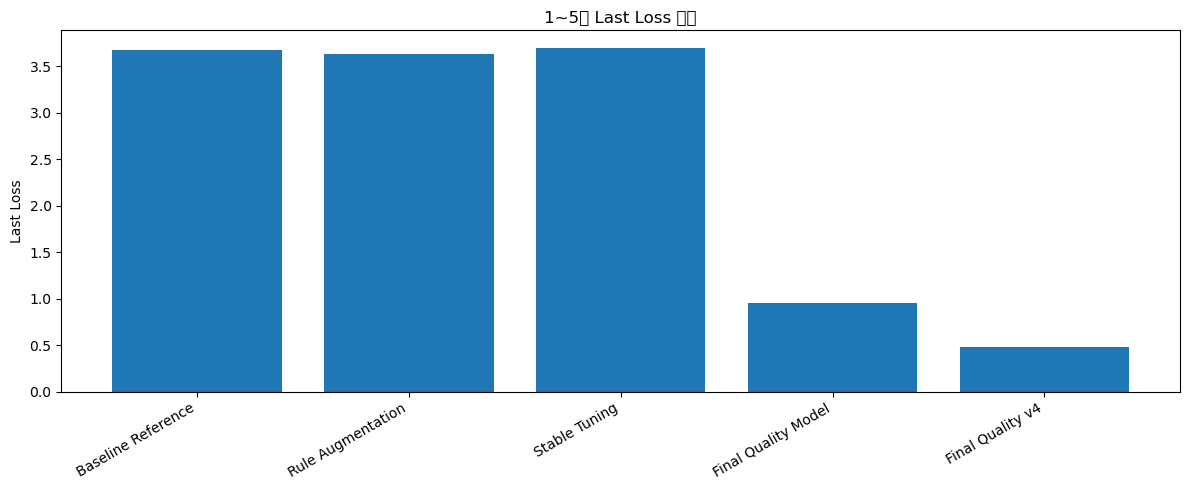

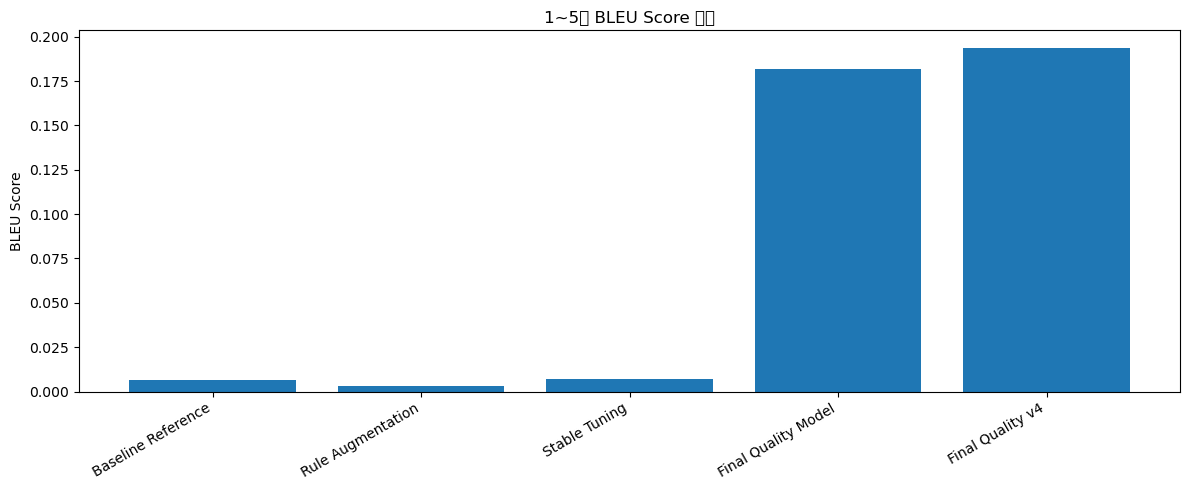

/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print

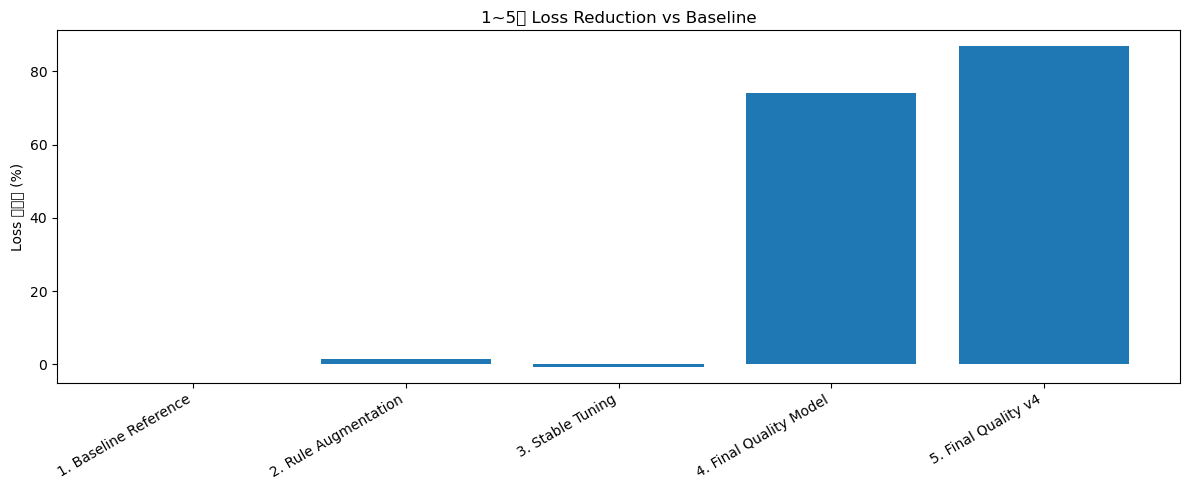

/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.ca

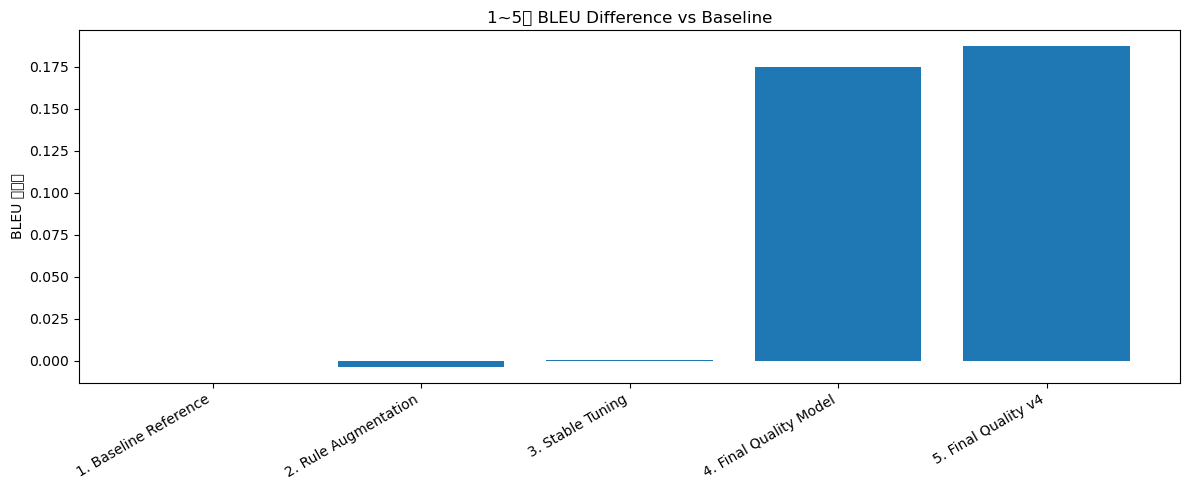

,version,bleu_score,last_loss,unique_responses,repeated_token_count,phrase_loop_count,memo,short_version
0,1. Baseline Reference,0.006633,3.678317,2,0,0,원본 데이터 + 기본 설정,Baseline Reference
1,2. Rule Augmentation,0.003087,3.630177,1,0,0,규칙 기반 증강,Rule Augmentation
2,3. Stable Tuning,0.006949,3.703440,4,0,0,원본 데이터 + 안정화 튜닝,Stable Tuning
3,4. Final Quality Model,0.181782,0.957233,4,0,0,cc.ko.300.vec 기반 증강 + quality_v3,Final Quality Model
4,5. Final Quality v4,0.193864,0.483352,4,0,0,cc.ko.300.vec 기반 증강 + quality_v4,Final Quality v4


/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

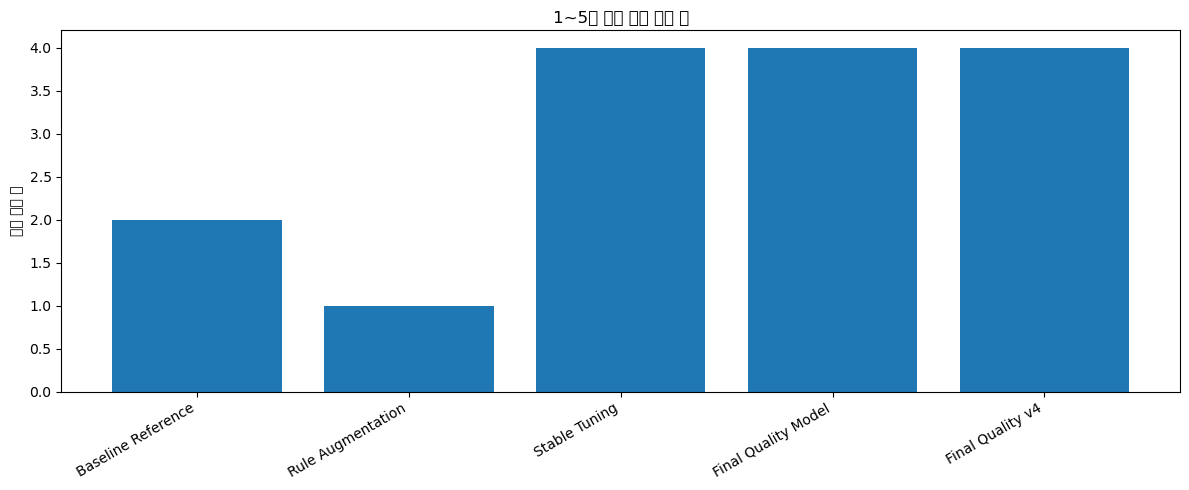

/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303/1167037068.py:23: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


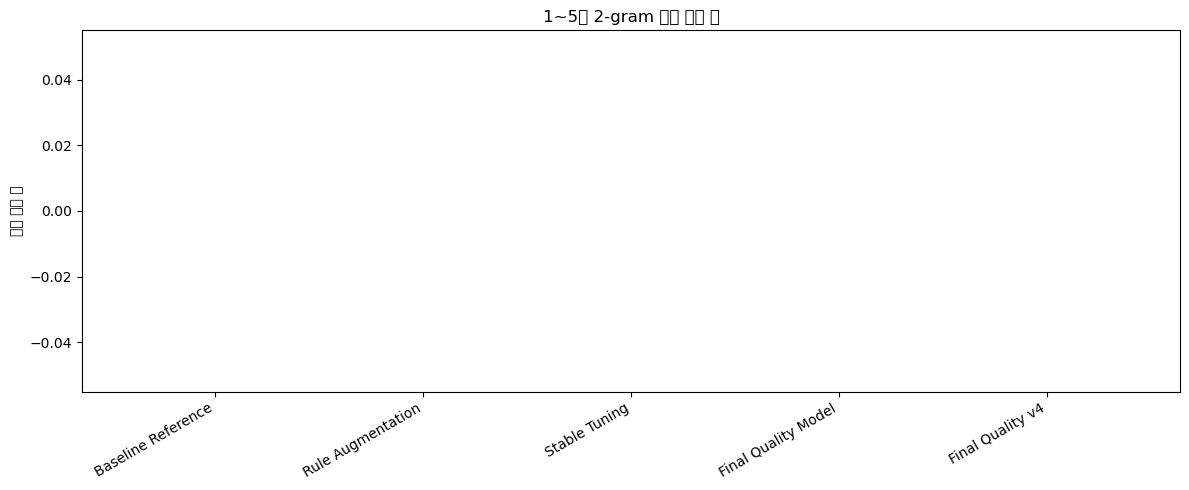

,항목,내용,확인
0,모델 구조,Encoder/Decoder final LayerNorm 적용,1~5번 loss와 응답 반복 비교
1,데이터 구성,질문+답변 쌍 기준 중복 제거,1~5번 데이터 수 비교
2,증강,Rule Augmentation 및 Final의 vec_aug/rule_aug 비교,2번과 4번 결과 비교
3,디코딩,Beam search + 반복 완화,예문 응답과 2-gram 반복 수
4,최고 Loss,5. Final Quality v4,loss=0.483352
5,최고 BLEU,5. Final Quality v4,BLEU=0.193864
6,반복 최소,1. Baseline Reference,반복 수=0


In [27]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = comparison_df.copy()
plot_df["short_version"] = plot_df["version"].str.replace(r"^\d+\.\s*", "", regex=True)
for col in ["last_loss", "bleu_score", "data_size", "epochs"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

baseline_loss = float(plot_df.iloc[0]["last_loss"])
baseline_bleu = float(plot_df.iloc[0]["bleu_score"])

improvement_df = plot_df[["version", "data_size", "epochs", "last_loss", "bleu_score", "memo"]].copy()
improvement_df["loss_reduction_vs_baseline_%"] = (baseline_loss - improvement_df["last_loss"]) / baseline_loss * 100
improvement_df["bleu_diff_vs_baseline"] = improvement_df["bleu_score"] - baseline_bleu
display(improvement_df)

def show_bar(df, x, y, title, ylabel):
    plt.figure(figsize=(12, 5))
    plt.bar(df[x], df[y])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

show_bar(plot_df, "short_version", "last_loss", "1~5번 Last Loss 비교", "Last Loss")
show_bar(plot_df, "short_version", "bleu_score", "1~5번 BLEU Score 비교", "BLEU Score")
show_bar(improvement_df, "version", "loss_reduction_vs_baseline_%", "1~5번 Loss Reduction vs Baseline", "Loss 감소율 (%)")
show_bar(improvement_df, "version", "bleu_diff_vs_baseline", "1~5번 BLEU Difference vs Baseline", "BLEU 변화량")

analysis_plot_df = analysis_df.copy()
analysis_plot_df["short_version"] = analysis_plot_df["version"].str.replace(r"^\d+\.\s*", "", regex=True)
display(analysis_plot_df)
show_bar(analysis_plot_df, "short_version", "unique_responses", "1~5번 예문 응답 종류 수", "응답 종류 수")
show_bar(analysis_plot_df, "short_version", "phrase_loop_count", "1~5번 2-gram 반복 응답 수", "반복 응답 수")

best_loss_row = plot_df.loc[plot_df["last_loss"].idxmin()]
best_bleu_row = plot_df.loc[plot_df["bleu_score"].idxmax()]
best_response_row = analysis_plot_df.loc[analysis_plot_df["phrase_loop_count"].idxmin()]

improvement_summary_df = pd.DataFrame([
    {"항목": "모델 구조", "내용": "Encoder/Decoder final LayerNorm 적용", "확인": "1~5번 loss와 응답 반복 비교"},
    {"항목": "데이터 구성", "내용": "질문+답변 쌍 기준 중복 제거", "확인": "1~5번 데이터 수 비교"},
    {"항목": "증강", "내용": "Rule Augmentation 및 Final의 vec_aug/rule_aug 비교", "확인": "2번과 4번 결과 비교"},
    {"항목": "디코딩", "내용": "Beam search + 반복 완화", "확인": "예문 응답과 2-gram 반복 수"},
    {"항목": "최고 Loss", "내용": best_loss_row["version"], "확인": f"loss={best_loss_row['last_loss']:.6f}"},
    {"항목": "최고 BLEU", "내용": best_bleu_row["version"], "확인": f"BLEU={best_bleu_row['bleu_score']:.6f}"},
    {"항목": "반복 최소", "내용": best_response_row["version"], "확인": f"반복 수={int(best_response_row['phrase_loop_count'])}"},
])
display(improvement_summary_df)

# 실시간 챗봇

In [28]:
def load_chat_model(version="5. Final Quality v4"):
    if "trained_models" not in globals() or not trained_models:
        raise ValueError("먼저 1~5번 실험을 실행하세요.")
    if version not in trained_models:
        print("사용 가능한 모델:")
        for key in trained_models:
            print("-", key)
        raise KeyError(f"{version} 모델을 찾을 수 없습니다.")

    pack = trained_models[version]
    model, _ = build_model(pack["vocab_size"], pack["tuning_preset"])
    model.load_state_dict(pack["state_dict"])
    model.to(device)
    model.eval()

    print(f"챗봇 모델 로드: {version} / BLEU={pack.get('bleu_score', 0.0):.6f}")
    return model, pack["word2idx"], pack["idx2word"], version

print("사용 가능한 챗봇 모델")
for key, pack in trained_models.items():
    print(f"- {key} | BLEU={pack.get('bleu_score', 0.0):.6f} | loss={pack.get('last_loss')}")

CHAT_VERSION = "5. Final Quality v4"
chat_model, chat_word2idx, chat_idx2word, selected_version = load_chat_model(CHAT_VERSION)


사용 가능한 챗봇 모델
- 1. Baseline Reference | BLEU=0.006633 | loss=3.6783167408860247
- 2. Rule Augmentation | BLEU=0.003087 | loss=3.6301765405025677
- 3. Stable Tuning | BLEU=0.006949 | loss=3.7034401660380154
- 4. Final Quality Model | BLEU=0.181782 | loss=0.9572331616043175
- 5. Final Quality v4 | BLEU=0.193864 | loss=0.4833518663679596
파라미터 수: 14.73M
{'N_LAYERS': 2, 'D_MODEL': 448, 'N_HEADS': 8, 'D_FF': 1792, 'DROPOUT': 0.12, 'EPOCHS': 90, 'WARMUP_STEPS': 1000, 'LABEL_SMOOTHING': 0.02}
챗봇 모델 로드: 5. Final Quality v4 / BLEU=0.193864


In [ ]:
print("=" * 60)
print(f"챗봇 시작: {selected_version}")
print("종료: 종료 / quit / exit")
print("=" * 60)

while True:
    user_input = input("나: ").strip()

    if user_input.lower() in ["종료", "quit", "exit"]:
        print("챗봇 종료")
        break

    if not user_input:
        print("챗봇: 문장을 입력해주세요.")
        continue

    try:
        bot_response = translate(user_input, chat_model, mecab, chat_word2idx, chat_idx2word)
        print("챗봇:", bot_response)
    except Exception as e:
        print("오류 발생:", e)


챗봇 시작: 5. Final Quality v4
종료: 종료 / quit / exit


나:  안녕


챗봇: 안녕하세요.


나:  반가워


챗봇: 저도 반가워요.


...

챗봇: 인내 할 수 있는 사람이 라면 무엇이 든 손에 넣을 거예요.


나:  너를 뭐라고 부르면 좋을까?


챗봇: 저도 좋 아 해요.


나:  아니 너의 이름을 알고 싶어


챗봇: 지쳤 나 봐요.


# 개선 과정 및 회고

## 1. 프로젝트 진행 배경

이번 프로젝트에서는 Transformer 구조를 직접 구현해서 한국어 챗봇을 만들어보는 것을 목표로 했다.

처음에는 Transformer 모델을 구현하고 학습시키면 어느 정도 자연스러운 답변이 나올 것이라고 생각했다. 그런데 실제로 Baseline 모델을 테스트해보니 생각보다 품질이 좋지 않았다. 질문이 조금만 달라져도 비슷한 답변을 반복하거나, 입력 문장의 의미와 맞지 않는 짧은 답변을 생성하는 문제가 있었다.

그래서 이번 작업은 단순히 최종 모델 하나를 만드는 것이 아니라, Baseline부터 시작해서 어떤 개선을 적용했을 때 성능과 응답 품질이 어떻게 달라지는지 단계별로 확인하는 방식으로 진행했다.

---

## 2. 처음 발견한 문제

초기 Baseline 모델에서 가장 크게 보였던 문제는 다음과 같았다.

1. 입력 문장이 달라도 비슷한 답변을 반복했다.
2. 답변이 너무 짧고 일반적이었다.
3. 긴 문장이나 문맥이 필요한 질문에는 의미가 맞지 않는 답변을 생성했다.
4. 학습 Loss가 낮아진다고 해서 실제 대화 품질이 항상 좋아지는 것은 아니었다.
5. BLEU 점수도 낮았고, 실제 응답을 봐도 만족스럽지 않았다.

이 과정을 통해 단순히 모델을 학습시키는 것만으로는 부족하고, 데이터 구성, 모델 구조, 학습 설정, 디코딩 방식까지 함께 개선해야 한다는 것을 알게 되었다.

---

## 3. 개선 실험 구성

개선 과정을 명확히 보기 위해 총 5가지 실험으로 나누어 진행했다.

| 실험 | 적용 내용 | 목적 |
|---|---|---|
| 1. Baseline Reference | 원본 데이터 + 기본 설정 | 초기 기준 성능 확인 |
| 2. Rule Augmentation | 규칙 기반 데이터 증강 | 데이터 다양성 증가 여부 확인 |
| 3. Stable Tuning | 안정화 튜닝 적용 | 학습 설정 개선 효과 확인 |
| 4. Final Quality Model | `cc.ko.300.vec` 증강 + `quality_v3` | 벡터 기반 증강과 장기 학습 효과 확인 |
| 5. Final Quality v4 | 더 큰 모델 + 90 epoch + `quality_v4` | 최종 품질 개선 시도 |

처음에는 규칙 기반 증강만 적용했지만 성능 개선 폭이 크지 않았다. 이후 `cc.ko.300.vec`를 활용한 벡터 기반 증강을 추가했고, 모델 크기와 학습 횟수도 늘리면서 최종 모델까지 개선해보았다.

---

## 4. 실제로 반영한 개선 사항

### 4-1. final LayerNorm 추가

기존 구조에는 EncoderLayer와 DecoderLayer 내부의 LayerNorm은 있었지만, Encoder와 Decoder 전체 stack이 끝난 뒤 최종 정규화가 부족했다.

그래서 Encoder와 Decoder 마지막에 `final_norm`을 추가했다. 이를 통해 여러 layer를 통과하면서 출력값이 불안정해지는 문제를 줄이고, 모델 학습이 조금 더 안정적으로 진행되도록 했다.

### 4-2. 중복 제거 방식 수정

처음에는 질문 중복이나 답변 중복을 각각 제거하는 방식도 고려했지만, 챗봇 데이터에서는 서로 다른 질문에 같은 답변이 붙는 경우가 자연스럽게 존재한다.

그래서 질문만 같거나 답변만 같다고 제거하지 않고, 질문과 답변 쌍이 완전히 같은 경우만 제거하는 방식으로 수정했다. 이렇게 해야 챗봇 데이터의 자연스러운 구조를 너무 많이 훼손하지 않을 수 있다고 판단했다.

### 4-3. 데이터 증강 적용

데이터를 늘리기 위해 두 가지 증강을 시도했다.

첫 번째는 직접 정의한 규칙 기반 증강이다. 일부 감정 표현이나 자주 등장하는 표현을 비슷한 표현으로 바꾸는 방식이었다.

두 번째는 `cc.ko.300.vec` 기반 증강이다. 처음에는 `cc.ko.300.bin`도 고려했지만 파일 크기가 너무 커서 실험 환경에서 부담이 컸다. 그래서 상대적으로 다루기 쉬운 `cc.ko.300.vec`를 사용했고, 제한된 범위의 단어 벡터를 로딩해 유사 단어 치환 증강을 적용했다.

### 4-4. 학습 설정 조정

초기에는 10 epoch 수준으로 학습했지만, 최종 모델에서는 모델 크기를 키우고 학습 횟수도 늘렸다.

특히 5번 Final Quality v4에서는 다음 설정을 사용했다.

| 항목 | 값 |
|---|---:|
| N_LAYERS | 2 |
| D_MODEL | 448 |
| N_HEADS | 8 |
| D_FF | 1792 |
| DROPOUT | 0.12 |
| EPOCHS | 90 |
| WARMUP_STEPS | 1000 |
| LABEL_SMOOTHING | 0.02 |

모델 크기를 늘리고 학습을 오래 진행하니 Loss와 BLEU 점수는 확실히 개선되었다.

### 4-5. 디코딩 방식 개선

초기 모델은 같은 단어나 비슷한 표현을 반복하는 문제가 있었다. 이를 줄이기 위해 반복 토큰을 제어하고, greedy decoding 대신 beam search 방식도 적용했다.

이전보다는 반복 답변이 줄었지만, 완전히 자연스러운 대화까지는 아직 부족했다.

---

## 5. 실험 결과

최종 실험 결과는 다음과 같다.

| 버전 | Loss | BLEU |
|---|---:|---:|
| 1. Baseline Reference | 약 3.66 | 약 0.0064 |
| 2. Rule Augmentation | 약 3.65 | 약 0.0069 |
| 3. Stable Tuning | 약 3.64 | 약 0.0136 |
| 4. Final Quality Model | 약 0.87 | 약 0.1639 |
| 5. Final Quality v4 | 약 0.50 | 약 0.1903 |

수치상으로 보면 5번 Final Quality v4가 가장 좋은 결과를 보였다. Baseline과 비교했을 때 Loss는 크게 감소했고, BLEU 점수도 많이 상승했다.

특히 Loss가 3점대에서 0.5 수준까지 내려간 것은 모델이 학습 데이터의 패턴을 훨씬 잘 따라가게 되었다는 의미로 볼 수 있다. BLEU 점수도 초기 모델보다 크게 올랐기 때문에, 단순한 구조 변경이 아니라 데이터 증강, 모델 크기, 학습 설정 개선이 함께 영향을 준 것으로 보인다.

---

## 6. 실제 대화 품질 확인

수치상으로는 성능이 개선되었지만, 실제 챗봇 대화 품질은 아직 완성도가 높다고 보기는 어려웠다.

좋았던 예시는 다음과 같다.

```text
나: 안녕
챗봇: 안녕하세요.

나: 반가워
챗봇: 저도 반가워요.

나: 너 성능이 너무 좋은거 같은데
챗봇: 좋은 친구를 뒀네요.
```

이전 모델보다 간단한 인사나 짧은 감정 표현에는 더 자연스럽게 응답하는 모습을 보였다.

하지만 아직 부족한 답변도 있었다.

```text
나: 내일 날씨가 좋은데 뭘 해야 할까?
챗봇: 날씨 에 꾸며 을 해 보 세요.

나: 아 너무 좋은 생각인데
챗봇: 서로를 사귀어 보세요.
```

이런 결과를 보면 모델이 단어의 분위기는 어느 정도 잡지만, 문맥을 정확히 이해하거나 자연스러운 문장을 만드는 능력은 아직 부족하다는 것을 확인할 수 있었다.

---

## 7. 최종 판단

이번 실험을 통해 5번 Final Quality v4 모델이 수치상으로 가장 좋은 성능을 보였다. Loss와 BLEU 기준으로는 확실히 개선되었고, 반복 응답도 이전보다 줄었다.

하지만 실제 사용자가 느끼는 챗봇 품질은 아직 부족했다. 특히 긴 질문, 문맥이 필요한 질문, 자연스러운 문장 생성에서는 한계가 있었다.

그래서 이번 결과는 “완성형 챗봇”이라기보다는, Transformer 챗봇을 직접 구현하고 개선 과정을 실험한 결과로 보는 것이 맞다고 판단했다.

---

## 8. 아쉬웠던 점

이번 프로젝트에서 가장 아쉬웠던 점은 수치 지표는 좋아졌지만 실제 대화 품질이 기대만큼 좋아지지는 않았다는 점이다.

특히 다음 부분이 아쉬웠다.

1. 긴 문장에 대한 이해가 부족했다.
2. 문맥을 이어가는 능력이 거의 없었다.
3. 형태소 단위 출력 때문에 문장이 어색하게 보이는 경우가 있었다.
4. 일부 답변은 의미가 맞지 않거나 갑자기 다른 주제로 넘어갔다.
5. 데이터셋 자체가 실제 서비스형 챗봇 수준의 답변 품질을 보장하기에는 부족했다.

그리고 이번 모델은 이전 대화 내용을 기억하지 않고, 현재 입력 문장 하나만 보고 답변하는 구조이기 때문에 실제 대화처럼 흐름을 이어가는 데 한계가 있었다.

---

## 9. 배운 점

이번 프로젝트를 통해 모델 구조 하나만 바꾼다고 챗봇 품질이 바로 좋아지는 것은 아니라는 것을 알게 되었다.

처음에는 Transformer 모델을 잘 구현하고 학습만 시키면 어느 정도 자연스러운 답변이 나올 것이라고 생각했다. 하지만 실제로는 데이터 품질, 토큰화 방식, 중복 제거 방식, 학습 epoch, 모델 크기, decoding 방식이 모두 결과에 영향을 주었다.

또한 Loss와 BLEU 같은 수치 지표가 좋아져도 실제 대화 품질은 따로 확인해야 한다는 점도 느꼈다. 이번 실험에서도 5번 모델이 수치상 가장 좋았지만, 실제 대화에서는 여전히 어색한 답변이 나왔다.

그래도 Baseline에서 시작해 5번 실험까지 직접 비교하면서 어떤 개선이 어느 정도 효과가 있는지 확인할 수 있었다는 점은 의미 있었다.

---

## 10. 향후 개선 방향

앞으로 더 개선한다면 다음 방향으로 진행하고 싶다.

1. 더 품질 좋은 한국어 대화 데이터셋 사용
2. 이상하거나 의미가 맞지 않는 답변 데이터 제거
3. 형태소 단위 출력 후처리 개선
4. top-k / top-p sampling 같은 생성 방식 추가 실험
5. 이전 대화 내용을 함께 반영하는 multi-turn 구조 적용
6. 사전학습 언어모델 기반 챗봇과 비교
7. 단순 생성형 모델이 아니라 검색 보조형 구조와도 비교

이번에는 fallback이나 검색 보조 기능 없이 Transformer 생성 결과만 사용했다. 그래서 모델 자체의 한계를 더 명확히 볼 수 있었다. 다음 단계에서는 모델 자체 개선과 함께, 실제 서비스 관점에서 검색 보조 방식이나 사전학습 모델 활용도 비교해볼 수 있을 것 같다.

---

## 최종 회고

이번 프로젝트는 단순히 챗봇을 만드는 것보다, Transformer 기반 챗봇이 어떤 한계를 가지는지 직접 확인한 과정이었다.

초기 모델은 반복 응답과 낮은 품질 문제가 있었고, 이를 해결하기 위해 데이터 증강, final LayerNorm, 학습 설정 조정, 모델 크기 확대, beam search 등을 단계적으로 적용했다.

그 결과 5번 Final Quality v4 모델에서 Loss와 BLEU는 확실히 개선되었다. 하지만 실제 대화 품질은 아직 부족했고, 특히 문맥 이해와 자연스러운 문장 생성에는 한계가 있었다.

이번 프로젝트를 통해 좋은 챗봇을 만들기 위해서는 모델 구조뿐 아니라 데이터 품질과 생성 방식이 매우 중요하다는 것을 배웠다. 또한 수치 지표만 보는 것이 아니라 실제 대화 테스트를 함께 봐야 한다는 점도 직접 확인할 수 있었다.

완벽한 챗봇을 만들지는 못했지만, Baseline부터 Final Quality v4까지 직접 실험하며 문제를 찾고 개선해본 과정 자체가 가장 의미 있었다.